In [1]:
import pandas as pd
import numpy as np
import re
import json
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy
import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)

In [3]:
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

data= pd.read_csv("anti_total.csv".strip('\u202a'), index_col=False)
# data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [4]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [7]:
final_cols = col_sum[col_sum >= 50].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [8]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            5515.0
Flomoxef                               5196.0
Cefazolin                              2371.0
Cefixime                               2166.0
Ciprofloxacin                          2071.0
Azithromycin                           2053.0
Cefuroxime                             1691.0
Piperacillin/Tazobactam                1511.0
Cefoperazone/sulbactam                 1412.0
Peramivir                              1119.0
Baloxavir marboxil                     1085.0
Metronidazole                          1020.0
Cefadroxil                              918.0
Oseltamivir                             835.0
Levofloxacin                            720.0
Clindamycin                             624.0
Gentamicin                              623.0
Ceftriaxone                             610.0
Cephalexin                              517.0
Ampicillin                              423.0
Amoxicillin                             388.0
Doxycycline                       

In [9]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [10]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter = data_filter.copy()
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [13]:
X.shape, y.shape

((27968, 70), (27968, 34))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0', 'Bacteria level', 'MAP'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir'])#, 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 在 drop 欄位後，先強迫 X 和 y 的索引同步
# 確保兩者擁有完全一樣的病患 ID (Index)
common_idx = X.index.intersection(y.index)
X = X.loc[common_idx]
y = y.loc[common_idx]

# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X.loc[has_label_mask]
y = y.loc[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

原本樣本數: 27968
過濾後樣本數: 25084
已刪除 2884 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['CHECKITEM29SCORE', 'RBC', 'HST', 'Na', 'Microscopic RBC level',
       'Microscopic WBC level', 'WBC', 'PH', 'INFECTIONSITE5', 'CHECKITEM28A',
       'Lymphocyte', 'CHECKITEM30SCORE', 'OTHERINFECTIONSITE_flag', 'AGE',
       'Creatinine', 'Miss_INFECTSITE_flag', 'INR', 'HCO3', 'CNS',
       'CARDIOVASCULAR', 'INFECTIONSITE9', 'VITALSIGNSSPO2', 'VITALSIGNSGCS',
       'Ht', 'K', 'CHECKITEM32SCORE', 'Absolute Neutrophil count',
       'Nitrite level', 'GPT', 'VITALSIGNSDBP', 'CHECKITEM31SCORE',
       'INFECTIONSITE4', 'CHECKITEM28SCORE', 'LIVER', 'VITALSIGNSRR',
       'CHECKITEM27SCORE', 'FEVER', 'T.Bilirubin', 'Neutrophil Seg.', 'CRP',
       'CANCER', 'SEX', 'AUTOIMMUNE', 'VITALSIGNSPR', 'INJURELEVEL',
       'StayTime_hours', 'BE(ecf)', 'VITALSIGNSBT', 'INFECTIONSITE3', 'PT',
       'APTT', 'PLT', 'KIDNEY', 'DM', 'RESPIRATORY', 'Leukocyte level',
       'INFECTIONSITE1', 'Hb', 'O2 SAT', 'CHECKITEM27', 'PCO2',
       'INFECTIONSITE2'],
      dtype='object')

In [17]:
y[y.columns].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            5515.0
Flomoxef                               5196.0
Cefazolin                              2371.0
Cefixime                               2166.0
Ciprofloxacin                          2071.0
Azithromycin                           2053.0
Cefuroxime                             1691.0
Piperacillin/Tazobactam                1511.0
Cefoperazone/sulbactam                 1412.0
Metronidazole                          1020.0
Cefadroxil                              918.0
Levofloxacin                            720.0
Clindamycin                             624.0
Gentamicin                              623.0
Ceftriaxone                             610.0
Cephalexin                              517.0
Ampicillin                              423.0
Amoxicillin                             388.0
Doxycycline                             358.0
Nemonoxacin                             169.0
Acyclovir                               157.0
Valaciclovir                      

In [18]:
####################### Missing 20~60% #######################

# 檢驗

X['VITALSIGNSSPO2_flag'] = (
     X['VITALSIGNSSPO2'].fillna('').str.strip().ne('').astype(int))

X['Hb_flag'] = (
     X['Hb'].fillna('').str.strip().ne('').astype(int))

X['WBC_flag'] = (
     X['WBC'].fillna('').str.strip().ne('').astype(int))

X['Ht_flag'] = (
     X['Ht'].fillna('').str.strip().ne('').astype(int))

X['PLT_flag'] = (
     X['PLT'].fillna('').str.strip().ne('').astype(int))

X['Lymphocyte_flag'] = (
     X['Lymphocyte'].fillna('').str.strip().ne('').astype(int))

X['Neutrophil Seg._flag'] = (
     X['Neutrophil Seg.'].fillna('').str.strip().ne('').astype(int))

X['Absolute Neutrophil count_flag'] = (
     X['Absolute Neutrophil count'].fillna('').str.strip().ne('').astype(int))

X['Na_flag'] = (
     X['Na'].fillna('').str.strip().ne('').astype(int))

X['K_flag'] = (
     X['K'].fillna('').str.strip().ne('').astype(int))

X['PLT_flag'] = (
     X['PLT'].fillna('').str.strip().ne('').astype(int))

X['Creatinine_flag'] = (
     X['Creatinine'].fillna('').str.strip().ne('').astype(int))

X['GPT_flag'] = (
     X['GPT'].fillna('').str.strip().ne('').astype(int))

X['CRP_flag'] = (
     X['CRP'].fillna('').str.strip().ne('').astype(int))

# 計分

####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))


X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


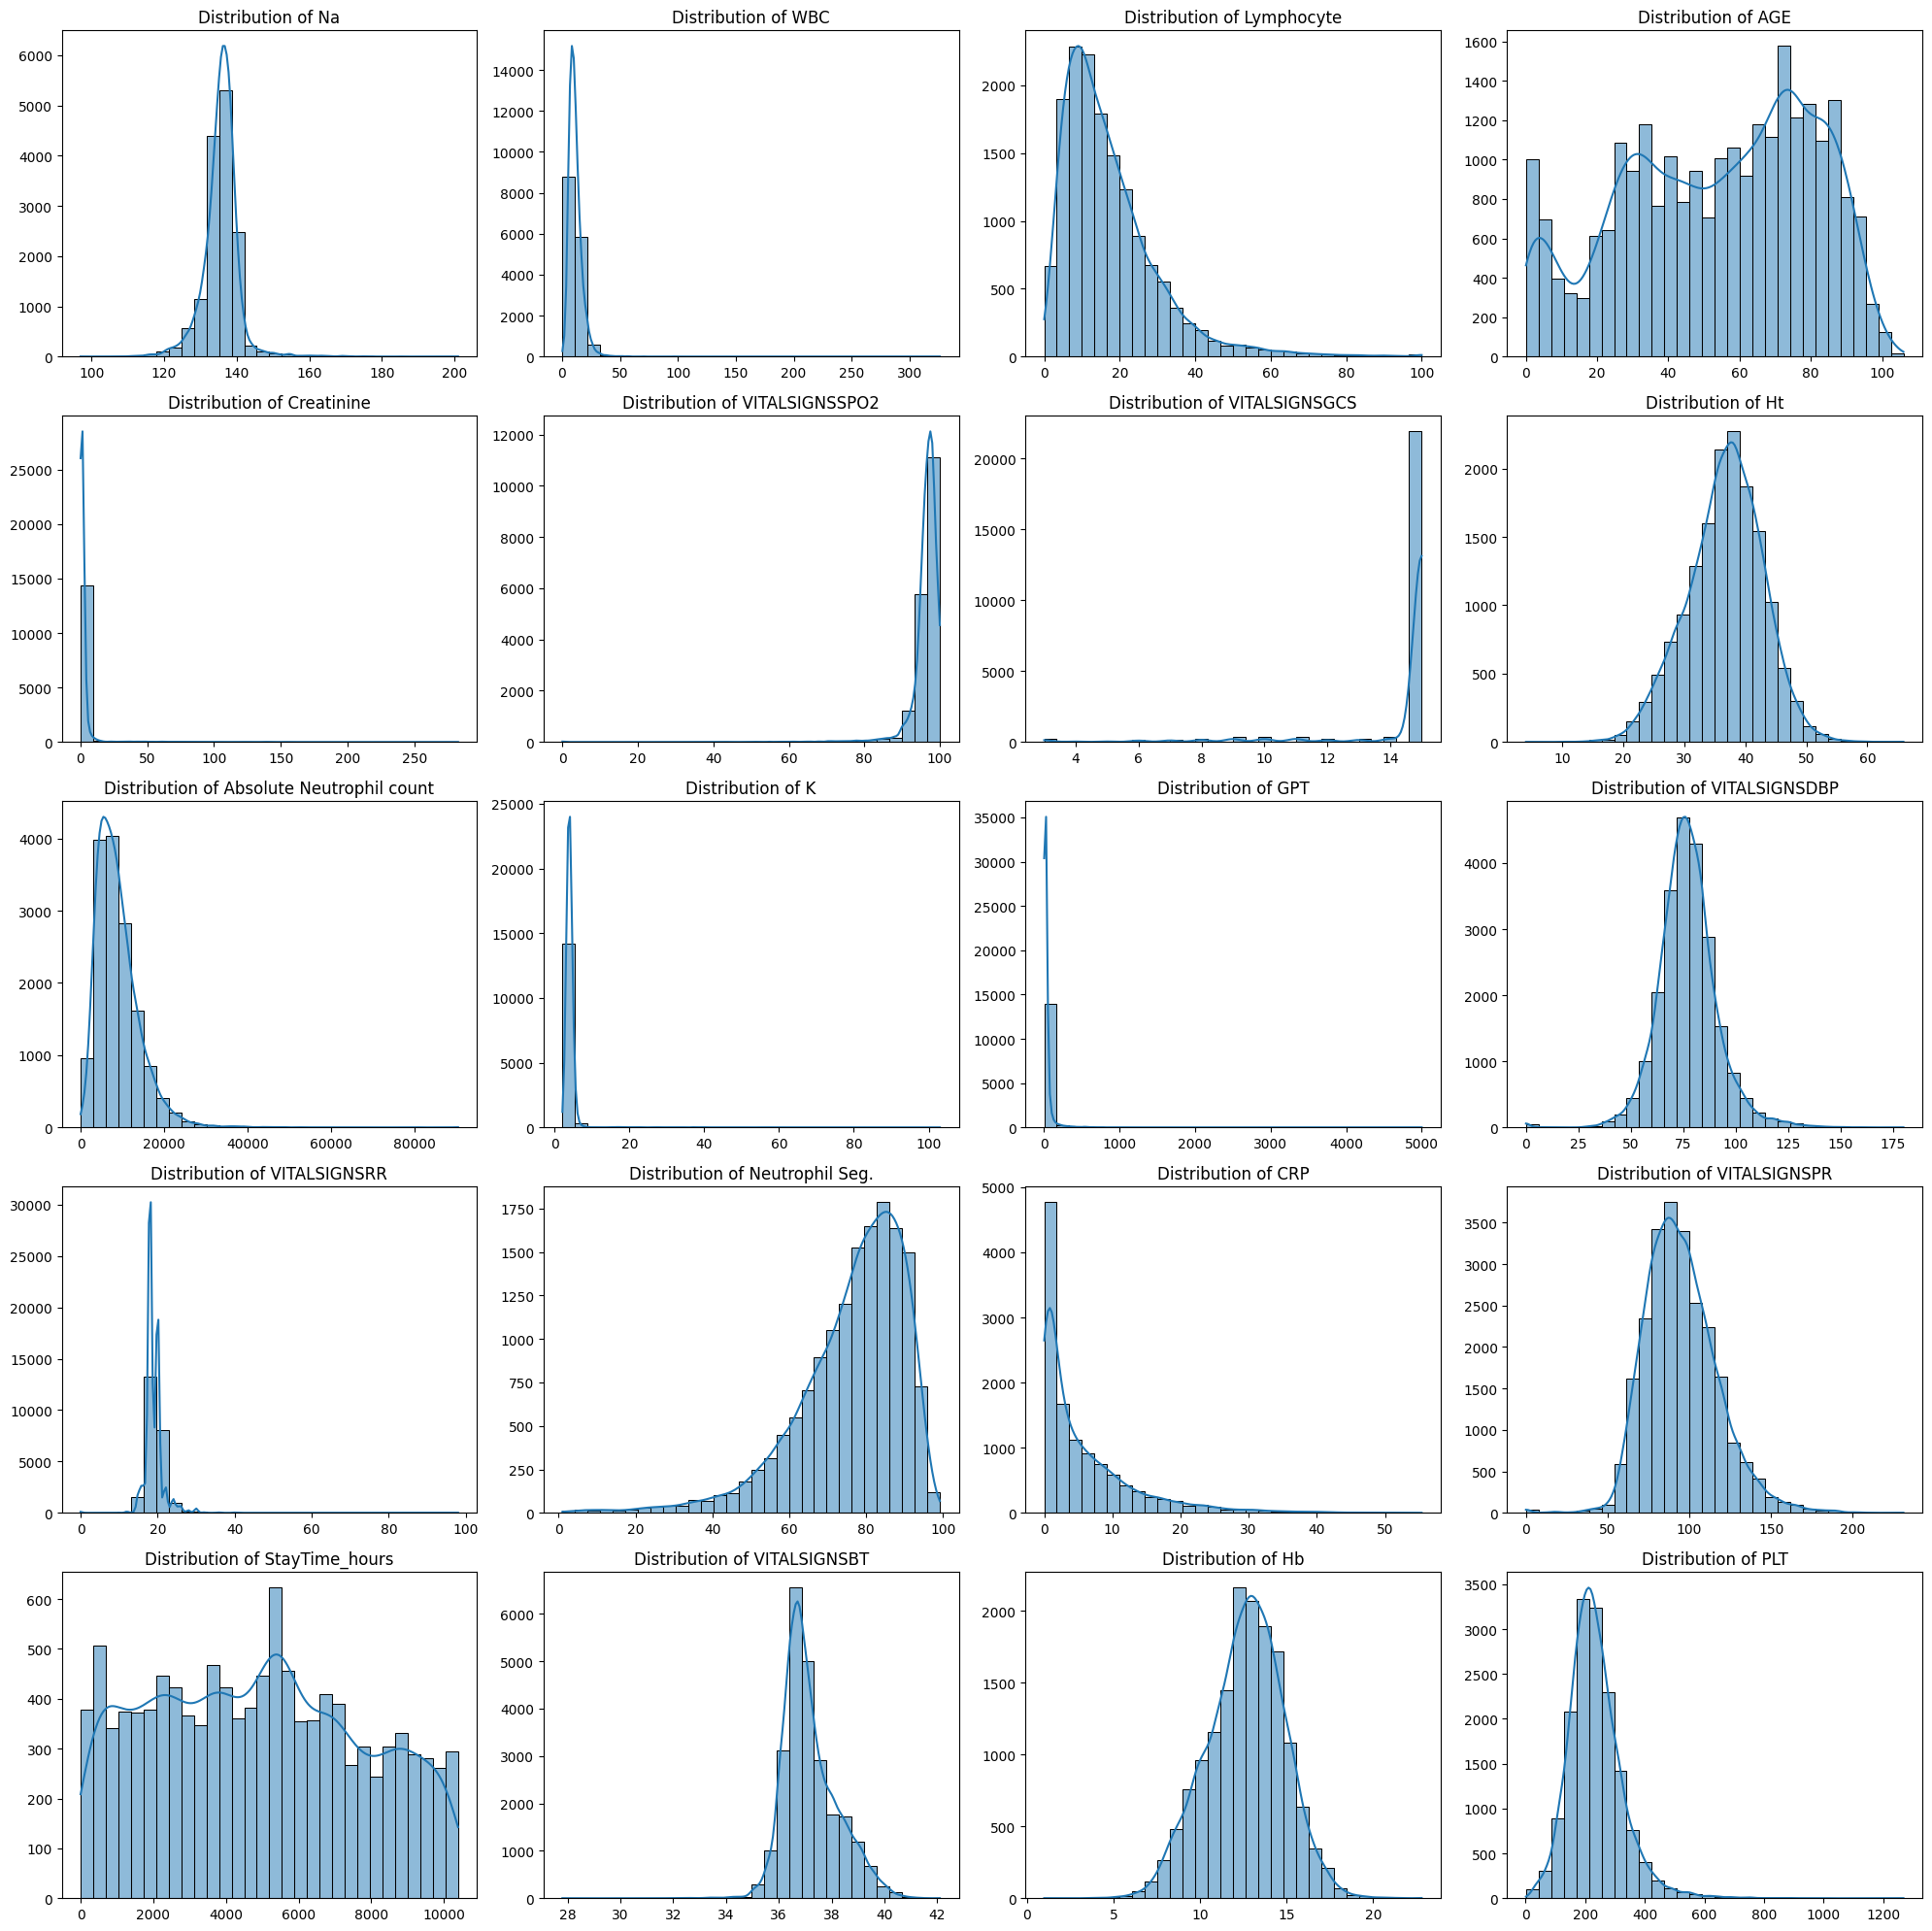

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 7386

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              236                   242   
VITALSIGNSDBP                             226                   227   
VITALSIGNSBT                              200                   205   
VITALSIGNSRR                              117                   228   
WBC                                       154                   154   
PLT                                       152                   153   
RBC                                       153                   152   
Absolute Neutrophil count                 152                   152   
Ht                                        151                   151   
Lymphocyte                                146                   152   

                           Total_Outliers  
VITALSIGNSPR                          478  
VITALSIGNSDBP                         453  
VITALSIGNSBT                          405  
VITAL

In [21]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((20067, 97), (20067, 31), (5017, 97), (5017, 31))

In [23]:
# 對齊index

X_train = X_train.copy()
y_train = y_train.copy()

X_test = X_test.copy()
y_test = y_test.copy()

X_train.index = range(len(X_train))
y_train.index = range(len(y_train))

X_test.index = range(len(X_test))
y_test.index = range(len(y_test))

In [24]:
X_train.isnull().sum(), X_test.isnull().sum()

(CHECKITEM29SCORE         15700
 RBC                       7792
 HST                      16234
 Na                        8234
 Microscopic RBC level    14212
                          ...  
 CHECKITEM27_flag             0
 CHECKITEM27SCORE_flag        0
 CHECKITEM28SCORE_flag        0
 CHECKITEM31SCORE_flag        0
 CHECKITEM32SCORE_flag        0
 Length: 97, dtype: int64,
 CHECKITEM29SCORE         3959
 RBC                      1982
 HST                      4141
 Na                       2106
 Microscopic RBC level    3567
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 97, dtype: int64)

In [25]:
X_train.dtypes, X_test.dtypes

(CHECKITEM29SCORE         float64
 RBC                      float64
 HST                      float64
 Na                       float64
 Microscopic RBC level    float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 97, dtype: object,
 CHECKITEM29SCORE         float64
 RBC                      float64
 HST                      float64
 Na                       float64
 Microscopic RBC level    float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 97, dtype: object)

In [26]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            4401.0
Flomoxef                               4135.0
Cefazolin                              1882.0
Cefixime                               1734.0
Ciprofloxacin                          1664.0
Azithromycin                           1645.0
Cefuroxime                             1370.0
Piperacillin/Tazobactam                1216.0
Cefoperazone/sulbactam                 1117.0
Metronidazole                           823.0
Cefadroxil                              737.0
Levofloxacin                            580.0
Clindamycin                             505.0
Ceftriaxone                             502.0
Gentamicin                              501.0
Cephalexin                              412.0
Ampicillin                              338.0
Amoxicillin                             297.0
Doxycycline                             286.0
Nemonoxacin                             141.0
Acyclovir                               129.0
Valaciclovir                      

In [27]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
            'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [28]:
# vital sign impute

vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
              'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
              'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [29]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['RBC'] = np.log1p(X_train['RBC'])
X_test['RBC'] = np.log1p(X_test['RBC'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

X_train['HST'] = np.log1p(X_train['HST'])
X_test['HST'] = np.log1p(X_test['HST'])

X_train['CHECKITEM27'] = np.log1p(X_train['CHECKITEM27'])
X_test['CHECKITEM27'] = np.log1p(X_test['CHECKITEM27'])

X_train['O2 SAT'] = np.log1p(X_train['O2 SAT'])
X_test['O2 SAT'] = np.log1p(X_test['O2 SAT'])

X_train['APTT'] = np.log1p(X_train['APTT'])
X_test['APTT'] = np.log1p(X_test['APTT'])

X_train['PH'] = np.log1p(X_train['PH'])
X_test['PH'] = np.log1p(X_test['PH'])

X_train['CHECKITEM28A'] = np.log1p(X_train['CHECKITEM28A'])
X_test['CHECKITEM28A'] = np.log1p(X_test['CHECKITEM28A'])

In [30]:
# fill score
# score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
#               'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
#               'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
#               'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
#               'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

score_cols = [
              'Leukocyte level', 'Nitrite level', 'Microscopic RBC level', 'Microscopic WBC level', 'PH',
              'CHECKITEM29SCORE', 'CHECKITEM30SCORE', # 70~80% missing
              'HST','T.Bilirubin', 'PT', 'HST', 'INR', 'APTT', 'PCO2', 'HCO3', 'BE(ecf)',
              'O2 SAT', 'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 
              'CHECKITEM31SCORE', 'CHECKITEM32SCORE'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [31]:
y_train.sum(axis=1).mean() # 每人平均用1.4個抗生素

np.float64(1.2495141276722979)

In [32]:
# drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
#              'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
#              'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
#              'CHECKITEM31SCORE', 'CHECKITEM32SCORE', 'OTHERINFECTIONSITE_flag']

drop_cols = ['OTHERINFECTIONSITE_flag']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [33]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
               'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
               'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [34]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(20067, 96)

In [35]:
y_train.columns

Index(['Acyclovir', 'Amoxicillin', 'Amoxicillin/Clavulanic acid', 'Ampicillin',
       'Azithromycin', 'Cefadroxil', 'Cefazolin', 'Cefepime', 'Cefixime',
       'Cefoperazone/sulbactam', 'Cefotaxime', 'Ceftazidime', 'Ceftriaxone',
       'Cefuroxime', 'Cephalexin', 'Ciprofloxacin', 'Clindamycin',
       'Doxycycline', 'Flomoxef', 'Fosfomycin', 'Gentamicin', 'Levofloxacin',
       'Metronidazole', 'Moxifloxacin', 'Nemonoxacin',
       'Piperacillin/Tazobactam', 'Sulfamethoxazole/Trimethoprim',
       'Tenofovir alafenamide', 'Valaciclovir', 'Vancomycin',
       'tenofovir/emtricitabine/bictegravir'],
      dtype='object')

In [36]:
X_train.columns

Index(['CHECKITEM29SCORE', 'RBC', 'HST', 'Na', 'Microscopic RBC level',
       'Microscopic WBC level', 'WBC', 'PH', 'INFECTIONSITE5', 'CHECKITEM28A',
       'Lymphocyte', 'CHECKITEM30SCORE', 'AGE', 'Creatinine',
       'Miss_INFECTSITE_flag', 'INR', 'HCO3', 'CNS', 'CARDIOVASCULAR',
       'INFECTIONSITE9', 'VITALSIGNSSPO2', 'VITALSIGNSGCS', 'Ht', 'K',
       'CHECKITEM32SCORE', 'Absolute Neutrophil count', 'Nitrite level', 'GPT',
       'VITALSIGNSDBP', 'CHECKITEM31SCORE', 'INFECTIONSITE4',
       'CHECKITEM28SCORE', 'LIVER', 'VITALSIGNSRR', 'CHECKITEM27SCORE',
       'FEVER', 'T.Bilirubin', 'Neutrophil Seg.', 'CRP', 'CANCER', 'SEX',
       'AUTOIMMUNE', 'VITALSIGNSPR', 'INJURELEVEL', 'StayTime_hours',
       'BE(ecf)', 'VITALSIGNSBT', 'INFECTIONSITE3', 'PT', 'APTT', 'PLT',
       'KIDNEY', 'DM', 'RESPIRATORY', 'Leukocyte level', 'INFECTIONSITE1',
       'Hb', 'O2 SAT', 'CHECKITEM27', 'PCO2', 'INFECTIONSITE2',
       'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag', 'Ht_flag', 'PLT_flag',

In [37]:
# GaussianMixture?

In [38]:
cluster_features = ['WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count',
                    'VITALSIGNSBT', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2']

gmm = GaussianMixture(n_components=3, covariance_type='spherical', init_params  = 'k-means++', n_init=10, random_state=123)

In [39]:
X_train['cluster'] = gmm.fit_predict(X_train[cluster_features])
X_test['cluster'] = gmm.predict(X_test[cluster_features])

In [40]:
gmm.aic(X_train[cluster_features]), gmm.bic(X_train[cluster_features]), gmm.score(X_train[cluster_features])

(np.float64(479661.87411953084),
 np.float64(479938.61323791335),
 np.float64(-11.949765139770042))

In [41]:
# 依平均數排序 mapping

summary = X_train.groupby('cluster').mean()

# 'WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count', 'Hb',
# 'VITALSIGNSDBP', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2'

scaler = StandardScaler() # 再標準化一次，避免不同群的不同特徵沒被考慮
scaled = scaler.fit_transform(summary[cluster_features])
direction = np.array([+1, +1, -1, +1, +1,
                      -1, +1, +1, -1, -1])

severity_score = (scaled * direction).sum(axis=1)
summary['severity_score'] = severity_score

#排序
sorted_cluster = summary['severity_score'].sort_values().index

mapping = {old : new for new, old in enumerate(sorted_cluster)}
X_train['cluster'] = np.vectorize(mapping.get)(X_train['cluster'])
X_test['cluster'] = np.vectorize(mapping.get)(X_test['cluster'])

In [42]:
X_train['cluster'].unique()

array([1, 0, 2])

In [43]:
len(X_train[X_train['cluster'] == 0]), len(X_train[X_train['cluster'] == 1]), len(X_train[X_train['cluster'] == 2])
# 5358, 4670, 9019

(4994, 6134, 8939)

In [44]:
#看看每個cluster的抗生素種類和分配
X_train_cluster = X_train.copy()
df_analysis = pd.concat([X_train_cluster, y_train], axis=1)

In [45]:
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_rate = subset[y_train.columns].mean().sort_values(ascending=False)
    print(drug_rate.head(15))

cluster 0
Flomoxef                       0.251302
Amoxicillin/Clavulanic acid    0.144573
Piperacillin/Tazobactam        0.121946
Cefazolin                      0.117541
Azithromycin                   0.090909
Cefoperazone/sulbactam         0.088306
Cefixime                       0.070284
Cefuroxime                     0.053464
Ciprofloxacin                  0.051462
Gentamicin                     0.042050
Levofloxacin                   0.038046
Ceftriaxone                    0.034642
Metronidazole                  0.032239
Ampicillin                     0.021025
Clindamycin                    0.014618
dtype: float64
cluster 1
Amoxicillin/Clavulanic acid    0.306325
Cefazolin                      0.100261
Flomoxef                       0.096348
Cefuroxime                     0.092436
Cefadroxil                     0.086730
Cefixime                       0.072383
Ciprofloxacin                  0.070916
Azithromycin                   0.064069
Cephalexin                     0.040104
Amoxi

In [46]:
# 相對提升
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate).sort_values(ascending=False) # 明顯偏?
    print(lift.head(15))

cluster 0
Cefepime                   3.327590
Cefotaxime                 2.537824
Ceftazidime                2.260250
Fosfomycin                 2.200455
Vancomycin                 2.176537
Piperacillin/Tazobactam    2.012415
Gentamicin                 1.684285
Cefoperazone/sulbactam     1.586424
Tenofovir alafenamide      1.552495
Ceftriaxone                1.384766
Levofloxacin               1.316314
Cefazolin                  1.253292
Ampicillin                 1.248264
Flomoxef                   1.219557
Azithromycin               1.108980
dtype: float64
cluster 1
tenofovir/emtricitabine/bictegravir    2.638256
Cefadroxil                             2.361472
Amoxicillin                            2.280093
Acyclovir                              2.130239
Valaciclovir                           2.064500
Cephalexin                             1.953334
Sulfamethoxazole/Trimethoprim          1.427537
Amoxicillin/Clavulanic acid            1.396735
Cefuroxime                             1.

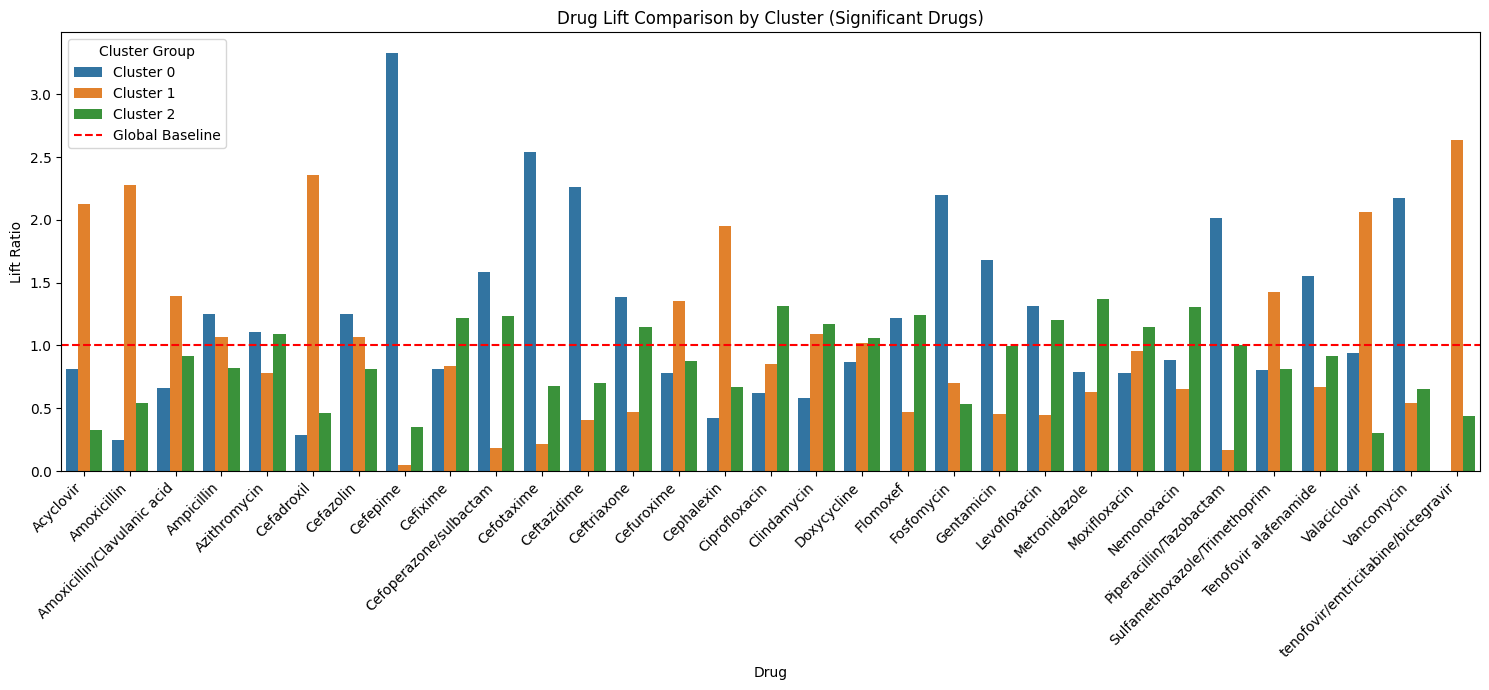

In [47]:
# 1. 整理資料存入 list
lift_records = []
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate)
    
    for drug, val in lift.items():
        lift_records.append({
            'Cluster': f'Cluster {c}',
            'Drug': drug,
            'Lift': val
        })

df_lift_plot = pd.DataFrame(lift_records)

# 2. 繪圖：只挑出 Lift 較顯著的藥物（例如 Lift > 1.5 的藥物）
# 否則藥物太多圖會擠在一起
significant_drugs = df_lift_plot[df_lift_plot['Lift'] > 1.0]['Drug'].unique()
df_filtered = df_lift_plot[df_lift_plot['Drug'].isin(significant_drugs)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_filtered, x='Drug', y='Lift', hue='Cluster')

# 畫一條紅線代表基準線 (Lift=1)
plt.axhline(1, ls='--', color='red', label='Global Baseline')

plt.title('Drug Lift Comparison by Cluster (Significant Drugs)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lift Ratio')
plt.legend(title='Cluster Group')
plt.tight_layout()
plt.show()


In [48]:
# 每群抗生素數量
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_num = subset[y_train.columns].sum(axis=1).mean()
    print(drug_num)

cluster 0
1.2735282338806568
cluster 1
1.1566677535050538
cluster 2
1.2998098221277548


In [49]:
# 挑選關鍵重症指標
severity_indicators = cluster_features

cols_to_show = [c for c in severity_indicators if c in cluster_features]

cluster_summary = X_train.groupby('cluster')[cols_to_show].mean().T
cluster_summary # 0:輕、1:中、2:重

cluster,0,1,2
WBC,-0.532579,-0.034891,0.321481
CRP,-0.139899,-0.039512,0.105271
Lymphocyte,0.894120,-0.173799,-0.380261
Neutrophil Seg.,-0.890687,0.145306,0.397895
Absolute Neutrophil count,-0.763802,0.041171,0.398466
VITALSIGNSBT,-0.060567,-0.512254,0.385349
VITALSIGNSRR,0.477926,-0.260295,-0.088390
VITALSIGNSPR,0.025612,-0.487833,0.320445
VITALSIGNSGCS,-0.706548,0.292178,0.194237
VITALSIGNSSPO2,-0.444408,0.263493,0.067469


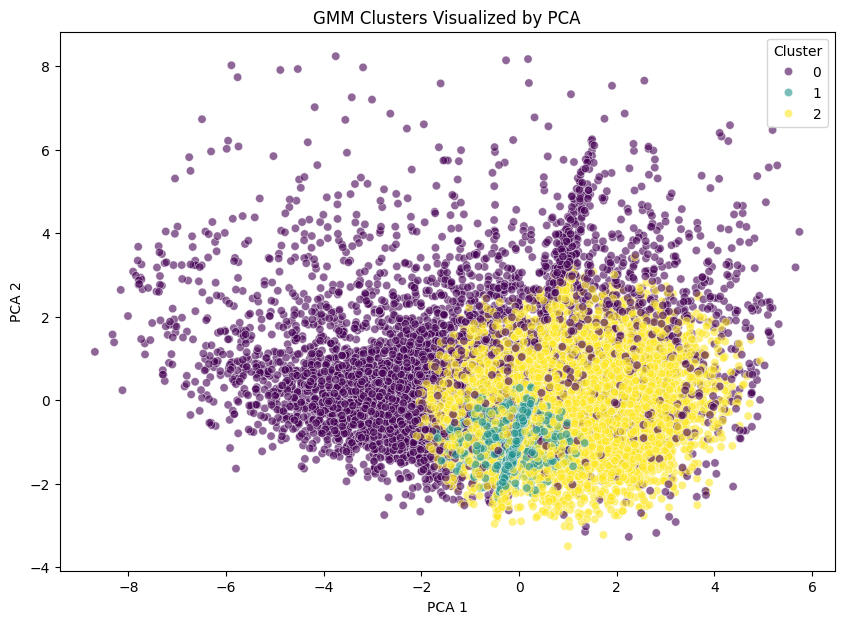

In [50]:
# PCA 降到 2 維
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train[cluster_features])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    hue=X_train['cluster'], # 根據 GMM 分群上色
    palette='viridis', 
    alpha=0.6
)

plt.title('GMM Clusters Visualized by PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


In [51]:
# cluster prob，並且排序sorted_cluster
cluster_prob_train = gmm.predict_proba(X_train[cluster_features])
cluster_prob_train = cluster_prob_train[:, sorted_cluster]
cluster_prob_test = gmm.predict_proba(X_test[cluster_features])
cluster_prob_test = cluster_prob_test[:, sorted_cluster]

In [52]:
def cluster_prob(df, cluster_prob):
    cluster_df = pd.DataFrame(
        cluster_prob,
        columns=[f'cluster_{i}' for i in range(cluster_prob.shape[1])]
    )
    final_df = pd.concat([df.reset_index(drop=True), cluster_df], axis=1)
    return final_df

X_train = cluster_prob(X_train, cluster_prob_train)
X_test = cluster_prob(X_test, cluster_prob_test)

In [53]:
# X_train = X_train.drop(columns='cluster')
# X_test = X_test.drop(columns='cluster')

In [54]:
X_train

,CHECKITEM29SCORE,RBC,HST,Na,Microscopic RBC level,Microscopic WBC level,WBC,PH,INFECTIONSITE5,CHECKITEM28A,Lymphocyte,CHECKITEM30SCORE,AGE,Creatinine,Miss_INFECTSITE_flag,INR,HCO3,CNS,CARDIOVASCULAR,INFECTIONSITE9,VITALSIGNSSPO2,VITALSIGNSGCS,Ht,K,CHECKITEM32SCORE,Absolute Neutrophil count,Nitrite level,GPT,VITALSIGNSDBP,CHECKITEM31SCORE,INFECTIONSITE4,CHECKITEM28SCORE,LIVER,VITALSIGNSRR,CHECKITEM27SCORE,FEVER,T.Bilirubin,Neutrophil Seg.,CRP,CANCER,SEX,AUTOIMMUNE,VITALSIGNSPR,INJURELEVEL,StayTime_hours,BE(ecf),VITALSIGNSBT,INFECTIONSITE3,PT,APTT,PLT,KIDNEY,DM,RESPIRATORY,Leukocyte level,INFECTIONSITE1,Hb,O2 SAT,CHECKITEM27,PCO2,INFECTIONSITE2,VITALSIGNSSPO2_flag,Hb_flag,WBC_flag,Ht_flag,PLT_flag,Lymphocyte_flag,Neutrophil Seg._flag,Absolute Neutrophil count_flag,Na_flag,K_flag,Creatinine_flag,GPT_flag,CRP_flag,Leukocyte level_flag,Nitrite level_flag,Microscopic RBC level_flag,Microscopic WBC level_flag,PH_flag,CHECKITEM29SCORE_flag,CHECKITEM30SCORE_flag,HST_flag,T.Bilirubin_flag,PT_flag,INR_flag,APTT_flag,PCO2_flag,HCO3_flag,BE(ecf)_flag,O2 SAT_flag,CHECKITEM28A_flag,CHECKITEM27_flag,CHECKITEM27SCORE_flag,CHECKITEM28SCORE_flag,CHECKITEM31SCORE_flag,CHECKITEM32SCORE_flag,cluster,cluster_0,cluster_1,cluster_2
0,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,0.443415,-0.211256,1,-1.00,-1.0,0,1,0,1.209314,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,1.102449,-1.0,0,-1.0,0,-0.455081,-1.0,1,-1.0,0.162280,-0.034039,1,0,1,-1.099507,3.0,-0.001928,-0.015428,-1.103975,0,-1.0,-0.073475,0.059348,1,0,1,-1.0,0,0.060003,0.131854,0.027838,-1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000058,9.966732e-01,3.268708e-03
1,-1.0,-0.333354,-0.054464,0.083914,1.0,2.0,-0.725559,1.664860,0,0.072955,-0.186271,-1.0,-0.206401,-0.211256,1,0.86,-1.0,0,0,0,0.160148,0.299068,-0.566085,-0.138060,-1.0,0.056636,0.0,-0.123601,-0.323668,-1.0,0,-1.0,0,-0.455081,-1.0,1,-1.0,0.162280,-0.034039,0,0,0,-0.671440,2.0,-0.001928,-0.015428,-0.481510,0,9.9,-1.651193,-1.237691,1,0,0,3.0,0,-0.809710,0.131854,0.027838,-1.0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0.000002,9.997344e-01,2.640055e-04
2,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,-0.928178,-0.211256,1,-1.00,-1.0,0,0,0,0.513397,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,0.389390,-1.0,0,-1.0,0,-0.455081,-1.0,1,-1.0,0.162280,-0.034039,0,0,0,-0.100684,3.0,-0.001928,-0.015428,-1.103975,0,-1.0,-0.073475,0.059348,0,0,0,-1.0,0,0.060003,0.131854,0.027838,-1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000001,9.996503e-01,3.481642e-04
3,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,0.141794,-0.211256,0,-1.00,-1.0,0,0,0,-4.384743,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,-0.719812,-1.0,0,-1.0,1,2.384570,-1.0,1,-1.0,0.162280,-0.034039,0,0,1,-1.337322,1.0,0.596233,-0.015428,-1.843035,0,-1.0,-0.073475,0.059348,0,0,0,-1.0,1,0.060003,0.131854,0.027838,-1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.999995,3.611365e-48,4.652381e-06
4,0.0,-0.694495,-0.054464,0.948170,2.0,5.0,0.866585,-0.554671,0,1.422266,-1.141594,0.0,0.652267,-0.298853,0,-1.00,22.7,1,1,0,0.863095,0.299068,-0.921802,-0.138060,0.0,1.043878,1.0,-0.034401,-0.085982,-1.0,0,0.0,1,1.521804,0.0,0,-1.0,1.385727,0.844165,1,0,1,0.137131,2.0,-0.001928,-0.065210,2.774231,1,-1.0,-0.073475,-0.389407,1,0,1,4.0,0,-1.099615,-0.141945,-0.324513,35.0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,2,0.027180,2.271215e-29,9.728204e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [55]:
X_train.columns

Index(['CHECKITEM29SCORE', 'RBC', 'HST', 'Na', 'Microscopic RBC level',
       'Microscopic WBC level', 'WBC', 'PH', 'INFECTIONSITE5', 'CHECKITEM28A',
       'Lymphocyte', 'CHECKITEM30SCORE', 'AGE', 'Creatinine',
       'Miss_INFECTSITE_flag', 'INR', 'HCO3', 'CNS', 'CARDIOVASCULAR',
       'INFECTIONSITE9', 'VITALSIGNSSPO2', 'VITALSIGNSGCS', 'Ht', 'K',
       'CHECKITEM32SCORE', 'Absolute Neutrophil count', 'Nitrite level', 'GPT',
       'VITALSIGNSDBP', 'CHECKITEM31SCORE', 'INFECTIONSITE4',
       'CHECKITEM28SCORE', 'LIVER', 'VITALSIGNSRR', 'CHECKITEM27SCORE',
       'FEVER', 'T.Bilirubin', 'Neutrophil Seg.', 'CRP', 'CANCER', 'SEX',
       'AUTOIMMUNE', 'VITALSIGNSPR', 'INJURELEVEL', 'StayTime_hours',
       'BE(ecf)', 'VITALSIGNSBT', 'INFECTIONSITE3', 'PT', 'APTT', 'PLT',
       'KIDNEY', 'DM', 'RESPIRATORY', 'Leukocyte level', 'INFECTIONSITE1',
       'Hb', 'O2 SAT', 'CHECKITEM27', 'PCO2', 'INFECTIONSITE2',
       'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag', 'Ht_flag', 'PLT_flag',

In [56]:
base_model_cv = XGBClassifier(n_estimators=100,
                              max_depth=5,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              eval_metric='logloss',
                              gamma=0,
                              reg_alpha=2,
                              reg_lambda=0.0,
                              min_child_weight=1,
                              scale_pos_weight=3,
                              random_state =123,
                              n_jobs=-1
    )

In [57]:
kf = KFold(n_splits=5, shuffle=True, random_state=123)

##########################  F1 篩選 ##################################
num_labels = y_train.shape[1]
f1_scores = np.zeros(num_labels)

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = MultiOutputClassifier(base_model_cv)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    for i in range(num_labels):
        f1_scores[i] += f1_score(y_val.iloc[:, i], y_pred[:, i], zero_division=0)


f1_scores /= kf.get_n_splits()

In [58]:
y_train.columns, f1_scores

(Index(['Acyclovir', 'Amoxicillin', 'Amoxicillin/Clavulanic acid', 'Ampicillin',
        'Azithromycin', 'Cefadroxil', 'Cefazolin', 'Cefepime', 'Cefixime',
        'Cefoperazone/sulbactam', 'Cefotaxime', 'Ceftazidime', 'Ceftriaxone',
        'Cefuroxime', 'Cephalexin', 'Ciprofloxacin', 'Clindamycin',
        'Doxycycline', 'Flomoxef', 'Fosfomycin', 'Gentamicin', 'Levofloxacin',
        'Metronidazole', 'Moxifloxacin', 'Nemonoxacin',
        'Piperacillin/Tazobactam', 'Sulfamethoxazole/Trimethoprim',
        'Tenofovir alafenamide', 'Valaciclovir', 'Vancomycin',
        'tenofovir/emtricitabine/bictegravir'],
       dtype='object'),
 array([0.        , 0.        , 0.59263279, 0.74700243, 0.32530604,
        0.0080757 , 0.70744957, 0.32057883, 0.11668332, 0.28660611,
        0.42550244, 0.        , 0.2142051 , 0.25458747, 0.05103341,
        0.31421869, 0.3187228 , 0.02674562, 0.6726446 , 0.        ,
        0.58224054, 0.06888314, 0.36535508, 0.        , 0.13274414,
        0.43127504, 

In [59]:
##########################  F1 篩選 ##################################
selected_labels = [
    col for col, f1 in zip(y_train.columns, f1_scores)
    if f1 >= 0.05  # 或 0.1
]
print(selected_labels) # Cefadroxil


['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin', 'Cefazolin', 'Cefepime', 'Cefixime', 'Cefoperazone/sulbactam', 'Cefotaxime', 'Ceftriaxone', 'Cefuroxime', 'Cephalexin', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin', 'Levofloxacin', 'Metronidazole', 'Nemonoxacin', 'Piperacillin/Tazobactam', 'tenofovir/emtricitabine/bictegravir']


In [60]:
# 1. 重新過濾 y_train
y_train = y_train[selected_labels]

# 2. 記得 y_test 也要同步過濾，否則後續評估會報錯
y_test = y_test[selected_labels]

print(f"原本抗生素數量: {len(f1_scores)}")
print(f"保留後的數量: {len(selected_labels)}")


原本抗生素數量: 31
保留後的數量: 20


In [61]:
# 1. 計算 mask，並確保它與 y_train 具有相同的索引
common_idx = X_train.index.intersection(y_train.index)

X_train = X_train.loc[common_idx]
y_train = y_train.loc[common_idx]

keep_samples_mask = (y_train.sum(axis=1) > 0)
print(len(X_train), len(keep_samples_mask))
print(X_train.index.equals(y_train.index)) # 應該要回傳 True

# 2. 使用 .loc 進行過濾，這是最安全的方式
common_idx_test = X_test.index.intersection(y_test.index)

X_test = X_test.loc[common_idx_test]
y_test = y_test.loc[common_idx_test]

X_train = X_train.loc[keep_samples_mask]
y_train = y_train.loc[keep_samples_mask]

# 3. 對測試集也做同樣處理
keep_test_mask = (y_test.sum(axis=1) > 0)
X_test = X_test.loc[keep_test_mask]
y_test = y_test.loc[keep_test_mask]


20067 20067
True


In [62]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18622, 100), (4642, 100), (18622, 20), (4642, 20))

In [63]:
base_model = XGBClassifier(n_estimators=500,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=0,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=500, n_jobs=-1,
                                              num_parallel_tree=None,
                                              random_state=123, ...))

In [64]:
X_train

,CHECKITEM29SCORE,RBC,HST,Na,Microscopic RBC level,Microscopic WBC level,WBC,PH,INFECTIONSITE5,CHECKITEM28A,Lymphocyte,CHECKITEM30SCORE,AGE,Creatinine,Miss_INFECTSITE_flag,INR,HCO3,CNS,CARDIOVASCULAR,INFECTIONSITE9,VITALSIGNSSPO2,VITALSIGNSGCS,Ht,K,CHECKITEM32SCORE,Absolute Neutrophil count,Nitrite level,GPT,VITALSIGNSDBP,CHECKITEM31SCORE,INFECTIONSITE4,CHECKITEM28SCORE,LIVER,VITALSIGNSRR,CHECKITEM27SCORE,FEVER,T.Bilirubin,Neutrophil Seg.,CRP,CANCER,SEX,AUTOIMMUNE,VITALSIGNSPR,INJURELEVEL,StayTime_hours,BE(ecf),VITALSIGNSBT,INFECTIONSITE3,PT,APTT,PLT,KIDNEY,DM,RESPIRATORY,Leukocyte level,INFECTIONSITE1,Hb,O2 SAT,CHECKITEM27,PCO2,INFECTIONSITE2,VITALSIGNSSPO2_flag,Hb_flag,WBC_flag,Ht_flag,PLT_flag,Lymphocyte_flag,Neutrophil Seg._flag,Absolute Neutrophil count_flag,Na_flag,K_flag,Creatinine_flag,GPT_flag,CRP_flag,Leukocyte level_flag,Nitrite level_flag,Microscopic RBC level_flag,Microscopic WBC level_flag,PH_flag,CHECKITEM29SCORE_flag,CHECKITEM30SCORE_flag,HST_flag,T.Bilirubin_flag,PT_flag,INR_flag,APTT_flag,PCO2_flag,HCO3_flag,BE(ecf)_flag,O2 SAT_flag,CHECKITEM28A_flag,CHECKITEM27_flag,CHECKITEM27SCORE_flag,CHECKITEM28SCORE_flag,CHECKITEM31SCORE_flag,CHECKITEM32SCORE_flag,cluster,cluster_0,cluster_1,cluster_2
1,-1.0,-0.333354,-0.054464,0.083914,1.0,2.0,-0.725559,1.664860,0,0.072955,-0.186271,-1.0,-0.206401,-0.211256,1,0.86,-1.0,0,0,0,0.160148,0.299068,-0.566085,-0.138060,-1.0,0.056636,0.0,-0.123601,-0.323668,-1.0,0,-1.0,0,-0.455081,-1.0,1,-1.0,0.162280,-0.034039,0,0,0,-0.671440,2.0,-0.001928,-0.015428,-0.481510,0,9.9,-1.651193,-1.237691,1,0,0,3.0,0,-0.809710,0.131854,0.027838,-1.0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0.000002,9.997344e-01,2.640055e-04
2,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,-0.928178,-0.211256,1,-1.00,-1.0,0,0,0,0.513397,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,0.389390,-1.0,0,-1.0,0,-0.455081,-1.0,1,-1.0,0.162280,-0.034039,0,0,0,-0.100684,3.0,-0.001928,-0.015428,-1.103975,0,-1.0,-0.073475,0.059348,0,0,0,-1.0,0,0.060003,0.131854,0.027838,-1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000001,9.996503e-01,3.481642e-04
3,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,0.141794,-0.211256,0,-1.00,-1.0,0,0,0,-4.384743,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,-0.719812,-1.0,0,-1.0,1,2.384570,-1.0,1,-1.0,0.162280,-0.034039,0,0,1,-1.337322,1.0,0.596233,-0.015428,-1.843035,0,-1.0,-0.073475,0.059348,0,0,0,-1.0,1,0.060003,0.131854,0.027838,-1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.999995,3.611365e-48,4.652381e-06
4,0.0,-0.694495,-0.054464,0.948170,2.0,5.0,0.866585,-0.554671,0,1.422266,-1.141594,0.0,0.652267,-0.298853,0,-1.00,22.7,1,1,0,0.863095,0.299068,-0.921802,-0.138060,0.0,1.043878,1.0,-0.034401,-0.085982,-1.0,0,0.0,1,1.521804,0.0,0,-1.0,1.385727,0.844165,1,0,1,0.137131,2.0,-0.001928,-0.065210,2.774231,1,-1.0,-0.073475,-0.389407,1,0,1,4.0,0,-1.099615,-0.141945,-0.324513,35.0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,2,0.027180,2.271215e-29,9.728204e-01
5,-1.0,0.104217,-0.054464,0.083914,-1.0,-1.0,-0.004139,0.058475,0,0.072955,-0.186271,-1.0,-0.989242,-0.211256,1,-1.00,-1.0,0,0,0,0.160148,0.299068,0.040726,-0.138060,-1.0,0.056636,-1.0,-0.123601,-0.402897,-1.0,0,-1.0,0,0.580502,-1.0,1,-1.0,0.162280,-0.034039,0,1,1,-1.194633,3.0,1.403945,-0.015428,-0.173983,0,-1.0,-0.073475,0.059348,0,0,1,-1.0,0,0.060003,0.131854,0.027838,-1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000039,9.943862e-01,5.575080e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [65]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.8254256435084322
0.8934767906260956


In [66]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# # 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# ############################
# # 用y_train去計算f1，或用cv

# # 計算每種抗生素權重(F1/recall)
# drug_weight = []
# ############################
# # 1. 用y_train
# # for i, col in enumerate(y_train.columns):
# #     # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
# #     score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
# #     drug_weight.append(score)
    
# # drug_weight = np.clip(drug_weight, 1e-6, None)
# ###########################
# # 2. 用cv
# # 對每個sub model跑cv
# for i, col in enumerate(y_train.columns):
#     #取得每個子模型
#     model = multi_model.estimators_[i]
#     #5-fold
#     cv_predicts = cross_val_predict(model, X_train, y_train.iloc[:, i], cv=5, n_jobs=-1)
#     #真實的recall
#     recall = recall_score(y_train.iloc[:, i], cv_predicts, average='binary')
#     #轉為權重
#     weight = 1 / (recall + 1e-6)
#     drug_weight.append(weight)
    
# drug_weight = np.array(drug_weight)
# ###########################

# #  normalize
# drug_weight = drug_weight / drug_weight.mean()


In [67]:
drug_weight = []

for i in range(y_train.shape[1]):
    base_model = XGBClassifier(
                           n_estimators=500,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

    cv_pred = cross_val_predict(
        base_model,
        X_train,
        y_train.iloc[:, i],
        cv=5,
        method='predict',
        n_jobs=-1
    )

    recall = recall_score(y_train.iloc[:, i], cv_pred)
    
    weight = (1 / (recall + 0.1)) ** 0.5  
    drug_weight.append(weight)

drug_weight = np.array(drug_weight)
drug_weight = drug_weight / drug_weight.mean()

In [68]:
alpha = 0.05 # penalty
belta = 0.05

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = np.log(y_prob_list + 1e-6) - np.log(drug_freq ** alpha)
adjusted_scores = (np.log(y_prob_list + 1e-6)+ belta * np.log(drug_weight)- alpha * np.log(drug_freq))
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)

In [69]:
# # adjusted_scores Softmax
exp_scores = np.exp(adjusted_scores)
scores_softmax = exp_scores / exp_scores.sum(axis=1, keepdims=True)

In [70]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5126760563380282
0.35984376528063977


In [71]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

np.float64(0.4523624874335775)

In [72]:
hamming_loss(y_test, y_pred)

0.05776604911676002

In [73]:
# target_names = y_train.columns

# for i, col in enumerate(target_names):
#     print(f'-- {col} --')
#     print(classification_report(y_train.iloc[:, i], y_pred_train[:, i]))

In [74]:
k=5
hitk = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hitk}")
precisionk = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precisionk}")
recall_k = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_k}")
map_k = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_k}")

Hit@5: 0.9179233089185695
precision@5: 0.21800947867299766
Recall@5: 0.8868806548901335
MAP@5: 0.6602763416152042


In [75]:
topk_counts = np.zeros(num_labels)

topk_idx = np.argsort(y_prob_list, axis=1)[:, -3:]

for i in range(len(topk_idx)):
    for idx in topk_idx[i]:
        topk_counts[idx] += 1

In [76]:
hit1 = hit_rate_at_k(y_test.values, adjusted_scores, k=1)
hit1

0.5529943989659629

In [77]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, scores_softmax, y_test.values, drug_names, k=5)

實際給藥: ['Cefuroxime']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.3383)
2. Cefuroxime (Score: 0.2363)
3. Azithromycin (Score: 0.1120)
4. Cefixime (Score: 0.0978)
5. Ciprofloxacin (Score: 0.0841)
實際給藥: ['Azithromycin', 'Cefoperazone/sulbactam']

推薦藥物:
1. Flomoxef (Score: 0.3261)
2. Levofloxacin (Score: 0.1646)
3. Cefoperazone/sulbactam (Score: 0.1636)
4. Piperacillin/Tazobactam (Score: 0.1162)
5. Cefixime (Score: 0.0809)
實際給藥: ['Cefixime', 'Metronidazole']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.2788)
2. Ciprofloxacin (Score: 0.2721)
3. Cefixime (Score: 0.2352)
4. Azithromycin (Score: 0.1220)
5. Levofloxacin (Score: 0.0412)
實際給藥: ['Cefixime']

推薦藥物:
1. Ciprofloxacin (Score: 0.6636)
2. Cefixime (Score: 0.1512)
3. Cefuroxime (Score: 0.1320)
4. Amoxicillin/Clavulanic acid (Score: 0.0220)
5. Metronidazole (Score: 0.0102)
實際給藥: ['Ciprofloxacin']

推薦藥物:
1. Cefuroxime (Score: 0.3839)
2. Ciprofloxacin (Score: 0.2569)
3. Cefixime (Score: 0.2363)
4. Levofloxacin (Score: 0.0495)
5. Cefa

In [78]:
def explain_topk_patient(i, X, y_true, multi_model, scores, drug_names, k=3):
    x = X.iloc[i:i+1]
    probs = scores[i]

    topk_idx = np.argsort(probs)[-k:][::-1]

    actual_idx = np.where(y_true.iloc[i] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs}")
    print("="*60)
    cluster_columns = ['cluster_0', 'cluster_1', 'cluster_2']
    cluster_prob = X.iloc[i][cluster_columns].values
    cluster_map = {0:'表現較嚴重', 1:'表現中等', 2:'表現較輕微'}
    
    print("病人嚴重傾向機率分布:")
    for idx, prob in enumerate(cluster_prob):
        # 格式化為百分比，方便閱讀
        print(f"  - {cluster_map[idx]:<6}: {prob*100:>5.1f}%")
    
    # 「主要傾向」
    cluster_label = np.argmax(cluster_prob)
    print(f"\n病人嚴重傾向: {cluster_map[cluster_label]}")

    for rank, idx in enumerate(topk_idx, 1):
        model = multi_model.estimators_[idx]
        # 0.令
        booster = model.get_booster()
        
        # 1. 將 pandas 的 x 轉換為 XGBoost 專用的 DMatrix
        dtrain = xgb.DMatrix(x)

        # 2. 執行預測取得 SHAP 值 (pred_contribs=True)
        # 這會回傳一個 numpy array，形狀為 (1, 特徵數 + 1)
        shap_matrix = booster.predict(dtrain, pred_contribs=True)

        # 3. 拿掉最後一欄 (Bias/Intercept)，只留特徵貢獻度
        shap_values = shap_matrix[:, :-1]
    ###############   
        # 4. 整理成 Series (注意：這裡不需要再呼叫 explainer.shap_values 了)
        # all_contrib = pd.Series(shap_values[0],index=X.columns)

        # 5. 篩選絕對值大於 0.1 的特徵 (即 > 0.1 或 < -0.1)
        # contrib = all_contrib[all_contrib.abs() > 0.1].sort_values(key=abs, ascending=False)
    ###############    
        # 5. 分出>0和<0兩部分，分別取平均，然後篩選出正的是大於平均、負的是小於平均的特徵，最後再依照其對值排序
        # 5.1. 整理成 Series
        all_contrib = pd.Series(shap_values[0], index=X.columns)
        # print(shap_values)

        # 5.2. 分離正負貢獻部分
        pos_part = all_contrib[all_contrib > 0]
        neg_part = all_contrib[all_contrib < 0]

        # 5.3. 分別計算平均並篩選 (加入 if 判斷避免該藥物完全沒有正/負向特徵時報錯)
        pos_contrib_filter = pd.Series(dtype=float)
        if not pos_part.empty:
            pos_mean = pos_part.mean()
            # 篩選出高於平均的正向特徵
            pos_contrib_filter = pos_part[pos_part >= pos_mean]

        neg_contrib_filter = pd.Series(dtype=float)
        if not neg_part.empty:
            neg_mean = neg_part.mean()
            # 篩選出低於平均 (即絕對值更大) 的負向特徵
            neg_contrib_filter = neg_part[neg_part <= neg_mean]

        # 5.4. 合併兩部分
        contrib = pd.concat([pos_contrib_filter, neg_contrib_filter])

        # 5.5. 移除群聚標籤
        contrib = contrib.drop(labels=['cluster_0', 'cluster_1', 'cluster_2', 'Miss_INFECTSITE_flag', 'StayTime_hours',
                                       'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag', 'Ht_flag', 'PLT_flag', 'Lymphocyte_flag', 
                                       'Neutrophil Seg._flag', 'Absolute Neutrophil count_flag', 'Na_flag', 'K_flag', 'PLT_flag', 
                                       'Creatinine_flag', 'GPT_flag', 'CRP_flag', 'Leukocyte level_flag', 'Nitrite level_flag',
                                       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag', 'CHECKITEM29SCORE_flag',
                                       'CHECKITEM30SCORE_flag', 'HST_flag', 'T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag',
                                       'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
                                       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 'CHECKITEM31SCORE_flag',
                                       'CHECKITEM32SCORE_flag', 'INJURELEVEL'], 
                               errors='ignore')
        
        # 5.6. 並依絕對值排序，如果篩選後特徵太多，最多只顯示前 10 個
        contrib = contrib.sort_values(key=abs, ascending=False).head(10)

        print(f"\n{rank}: {drug_names[idx]}")
        print(f"\nScore: {probs[idx]:.4f}")
        print("\n主要影響特徵 and Shap值:")
        total_impact = contrib.abs().sum()
        for feat, val in contrib.items():
            pct = (val / total_impact) * 100
            direction = "+" if val > 0 else "-" 
            print(f"{feat:<15}: {direction} {abs(pct):.1f}%")
            
        # print(contrib)
        print("-"*40)

In [79]:
# explain_topk_patient(0, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

In [80]:
for i in range(10):
    explain = explain_topk_patient(i, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

實際給藥: ['Cefuroxime']
病人嚴重傾向機率分布:
  - 表現較嚴重 :   0.6%
  - 表現中等  :  71.0%
  - 表現較輕微 :  28.5%

病人嚴重傾向: 表現中等

1: Amoxicillin/Clavulanic acid

Score: 0.3383

主要影響特徵 and Shap值:
KIDNEY         : - 18.9%
INFECTIONSITE2 : + 15.6%
VITALSIGNSRR   : + 10.2%
SEX            : - 9.8%
VITALSIGNSBT   : - 9.5%
INFECTIONSITE5 : - 8.8%
AGE            : + 8.2%
Nitrite level  : + 7.9%
INFECTIONSITE3 : + 6.0%
RESPIRATORY    : - 5.1%
----------------------------------------

2: Cefuroxime

Score: 0.2363

主要影響特徵 and Shap值:
KIDNEY         : + 19.7%
SEX            : + 17.5%
INFECTIONSITE1 : + 17.4%
VITALSIGNSSPO2 : + 8.4%
RBC            : - 7.3%
RESPIRATORY    : + 6.7%
VITALSIGNSBT   : + 6.2%
CHECKITEM30SCORE: - 5.8%
Microscopic WBC level: - 5.7%
VITALSIGNSRR   : - 5.4%
----------------------------------------

3: Azithromycin

Score: 0.1120

主要影響特徵 and Shap值:
VITALSIGNSRR   : - 17.9%
VITALSIGNSSPO2 : - 15.5%
RESPIRATORY    : - 12.8%
FEVER          : - 10.4%
VITALSIGNSPR   : - 8.6%
INFECTIONSITE2 : + 8.6%
AGE    